# Understanding Overfitting: Metrics Divergence & Weight Magnitudes

This notebook demonstrates two key indicators of overfitting:
1. **Train vs Test Metric Divergence** - Training error decreases but test error increases
2. **High Weight Coefficients** - Overfitted models have extremely large weights

These observations motivate the need for **regularization** techniques.

## Setup

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split

np.random.seed(42)

---
## 1. Generate Non-Linear Data with Noise

We create data following a sine wave pattern with added random noise.

In [ ]:
# Generate 30 data points
n_samples = 30
X = np.linspace(0, 1, n_samples).reshape(-1, 1)

# True pattern: sine wave
y_true = np.sin(2 * np.pi * X).ravel()

# Add random noise
noise = np.random.normal(0, 0.3, n_samples)
y = y_true + noise

In [ ]:
# Split into training (70%) and test (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

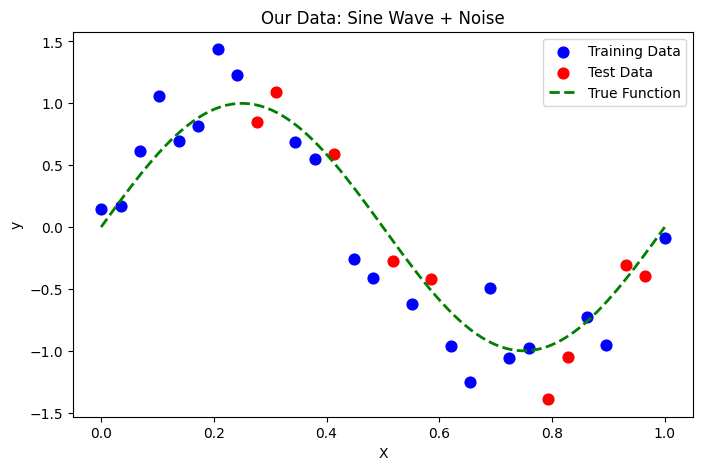

In [4]:
# Visualize the data
plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color='blue', s=60, label='Training Data')
plt.scatter(X_test, y_test, color='red', s=60, label='Test Data')

# Plot the true underlying function
X_smooth = np.linspace(0, 1, 100).reshape(-1, 1)
plt.plot(X_smooth, np.sin(2 * np.pi * X_smooth), 'g--', linewidth=2, label='True Function')

plt.xlabel('X')
plt.ylabel('y')
plt.title('Our Data: Sine Wave + Noise')
plt.legend()
plt.show()

---
## 2. What Does PolynomialFeatures Do?

It creates new columns by raising X to different powers.

In [5]:
import pandas as pd

# Create a simple dummy dataframe to demonstrate PolynomialFeatures

# Create a simple dataset
data = {
    'X1': [1, 2, 3, 4]
	#,
    #'X2': [5, 6, 7, 8]
}
df_demo = pd.DataFrame(data)

print("Original DataFrame:")
display(df_demo)
print("\n" + "="*60 + "\n")

# Demonstrate Degree 2
print("DEGREE 2 Polynomial Features:")
print("-" * 60)
poly_2 = PolynomialFeatures(degree=2, include_bias=False)
X_poly_2 = poly_2.fit_transform(df_demo)

df_poly_2 = pd.DataFrame(X_poly_2, columns=poly_2.get_feature_names_out(df_demo.columns))
display(df_poly_2)

Original DataFrame:


,X1
0,1
1,2
2,3
3,4




DEGREE 2 Polynomial Features:
------------------------------------------------------------


,X1,X1^2
0,1.0,1.0
1,2.0,4.0
2,3.0,9.0
3,4.0,16.0


---
## 3. Fit a Degree 1 Model (UNDERFITTING)

A straight line can't capture the sine wave pattern.

In [7]:
# Step 1: Create polynomial features (degree 1 = just X)
poly1 = PolynomialFeatures(degree=1, include_bias=False)
X_train_poly1 = poly1.fit_transform(X_train)
X_test_poly1 = poly1.transform(X_test)

# Step 2: Fit linear regression
model1 = LinearRegression()
model1.fit(X_train_poly1, y_train)

# Step 3: Predict
y_train_pred1 = model1.predict(X_train_poly1)
y_test_pred1 = model1.predict(X_test_poly1)

# Step 4: Calculate errors (MSE = Mean Squared Error)
train_mse_1 = np.mean((y_train - y_train_pred1) ** 2)
test_mse_1 = np.mean((y_test - y_test_pred1) ** 2)

# Step 5: Calculate weight magnitude
weight_norm_1 = np.sqrt(np.sum(model1.coef_ ** 2))

print(f"Train MSE: {train_mse_1:.4f}")
print(f"Test MSE:  {test_mse_1:.4f}")
print(f"Weight Norm: {weight_norm_1:.2f}")

Train MSE: 0.2878
Test MSE:  0.3036
Weight Norm: 2.03


In [ ]:
model1.coef_

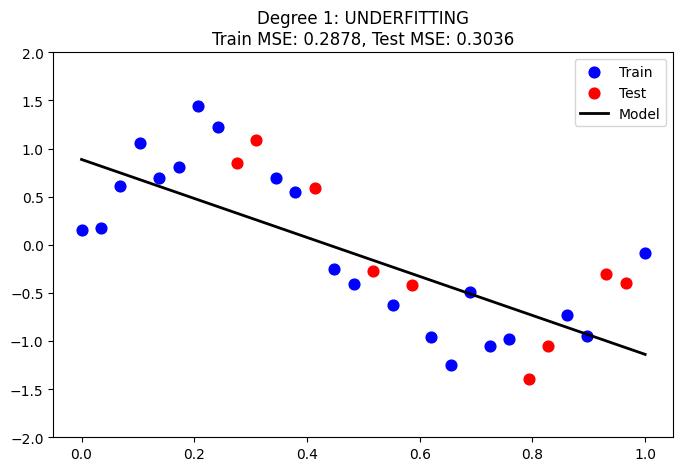

→ Model is too simple. High error on BOTH train and test.


In [8]:
# Visualize degree 1 fit
X_smooth_poly1 = poly1.transform(X_smooth)
y_smooth_pred1 = model1.predict(X_smooth_poly1)

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color='blue', s=60, label='Train')
plt.scatter(X_test, y_test, color='red', s=60, label='Test')
plt.plot(X_smooth, y_smooth_pred1, 'k-', linewidth=2, label='Model')
plt.ylim(-2, 2)
plt.title(f'Degree 1: UNDERFITTING\nTrain MSE: {train_mse_1:.4f}, Test MSE: {test_mse_1:.4f}')
plt.legend()
plt.show()

print("→ Model is too simple. High error on BOTH train and test.")

Train MSE: 0.2832
Test MSE:  0.2982
Weight Norm: 2.96


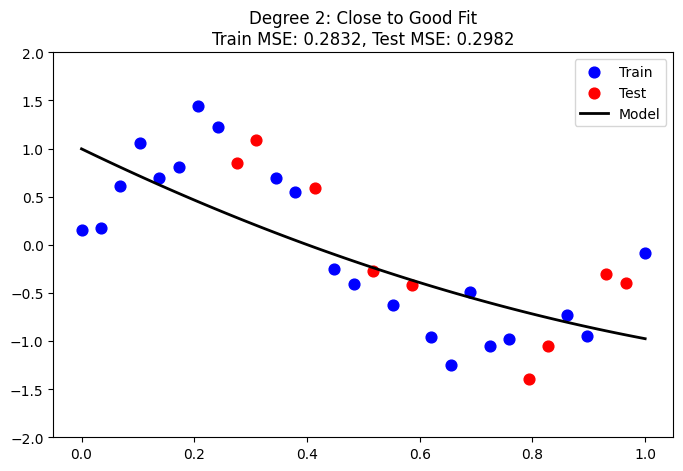

→ The degree 2 model is better than degree 1, but still not quite capturing the full curve.


In [9]:
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly2 = poly2.fit_transform(X_train)
X_test_poly2 = poly2.transform(X_test)

model2 = LinearRegression()
model2.fit(X_train_poly2, y_train)

y_train_pred2 = model2.predict(X_train_poly2)
y_test_pred2 = model2.predict(X_test_poly2)

train_mse_2 = np.mean((y_train - y_train_pred2) ** 2)
test_mse_2 = np.mean((y_test - y_test_pred2) ** 2)
weight_norm_2 = np.sqrt(np.sum(model2.coef_ ** 2))

print(f"Train MSE: {train_mse_2:.4f}")
print(f"Test MSE:  {test_mse_2:.4f}")
print(f"Weight Norm: {weight_norm_2:.2f}")

X_smooth_poly2 = poly2.transform(X_smooth)
y_smooth_pred2 = model2.predict(X_smooth_poly2)

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color='blue', s=60, label='Train')
plt.scatter(X_test, y_test, color='red', s=60, label='Test')
plt.plot(X_smooth, y_smooth_pred2, 'k-', linewidth=2, label='Model')
plt.ylim(-2, 2)
plt.title(f'Degree 2: Close to Good Fit\nTrain MSE: {train_mse_2:.4f}, Test MSE: {test_mse_2:.4f}')
plt.legend()
plt.show()

print("→ The degree 2 model is better than degree 1, but still not quite capturing the full curve.")

---
## 4. Fit a Degree 3 Model (GOOD FIT)

A cubic polynomial captures the pattern well.

In [10]:
# Create degree 3 features
poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly3 = poly3.fit_transform(X_train)
X_test_poly3 = poly3.transform(X_test)

# Fit model
model3 = LinearRegression()
model3.fit(X_train_poly3, y_train)

# Predict and calculate errors
y_train_pred3 = model3.predict(X_train_poly3)
y_test_pred3 = model3.predict(X_test_poly3)

train_mse_3 = np.mean((y_train - y_train_pred3) ** 2)
test_mse_3 = np.mean((y_test - y_test_pred3) ** 2)
weight_norm_3 = np.sqrt(np.sum(model3.coef_ ** 2))

print(f"Train MSE: {train_mse_3:.4f}")
print(f"Test MSE:  {test_mse_3:.4f}")
print(f"Weight Norm: {weight_norm_3:.2f}")

Train MSE: 0.0641
Test MSE:  0.0461
Weight Norm: 39.54


In [11]:
model3.coef_

array([  9.69738665, -31.53509694,  21.7845135 ])

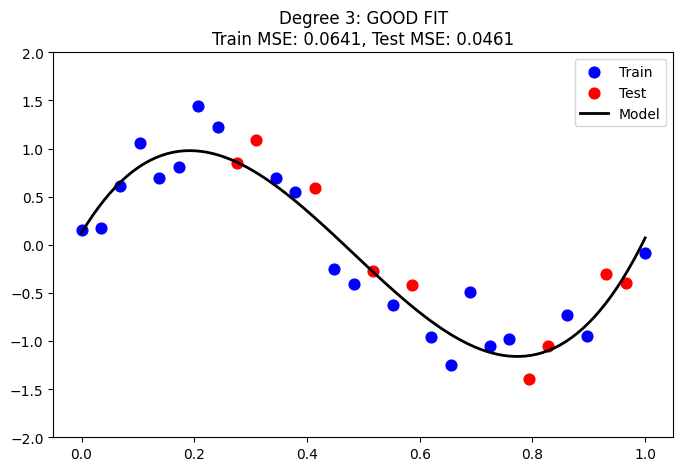

→ Model captures the pattern. Low error on both train and test.


In [12]:
# Visualize degree 3 fit
X_smooth_poly3 = poly3.transform(X_smooth)
y_smooth_pred3 = model3.predict(X_smooth_poly3)

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color='blue', s=60, label='Train')
plt.scatter(X_test, y_test, color='red', s=60, label='Test')
plt.plot(X_smooth, y_smooth_pred3, 'k-', linewidth=2, label='Model')
plt.ylim(-2, 2)
plt.title(f'Degree 3: GOOD FIT\nTrain MSE: {train_mse_3:.4f}, Test MSE: {test_mse_3:.4f}')
plt.legend()
plt.show()

print("→ Model captures the pattern. Low error on both train and test.")

---
## 5. Fit a Degree 15 Model (OVERFITTING)

Too many features → model memorizes noise!

In [13]:
# Create degree 15 features
poly15 = PolynomialFeatures(degree=15)
X_train_poly15 = poly15.fit_transform(X_train)
X_test_poly15 = poly15.transform(X_test)

# Fit model
model15 = LinearRegression()
model15.fit(X_train_poly15, y_train)

# Predict and calculate errors
y_train_pred15 = model15.predict(X_train_poly15)
y_test_pred15 = model15.predict(X_test_poly15)

train_mse_15 = np.mean((y_train - y_train_pred15) ** 2)
test_mse_15 = np.mean((y_test - y_test_pred15) ** 2)
weight_norm_15 = np.sqrt(np.sum(model15.coef_ ** 2))

print(f"Train MSE: {train_mse_15:.4f}")
print(f"Test MSE:  {test_mse_15:.4f}")
print(f"Weight Norm: {weight_norm_15:.2f}")

Train MSE: 0.0223
Test MSE:  461.7852
Weight Norm: 18199885221.94


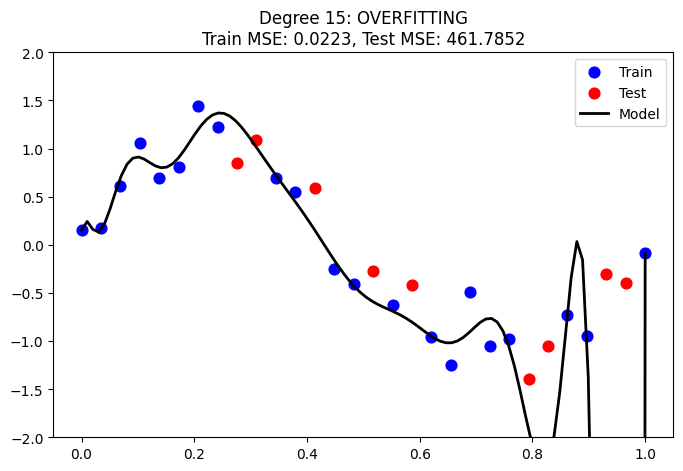

→ Model memorizes training data. Low train error, HIGH test error!


In [14]:
# Visualize degree 15 fit
X_smooth_poly15 = poly15.transform(X_smooth)
y_smooth_pred15 = model15.predict(X_smooth_poly15)

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color='blue', s=60, label='Train')
plt.scatter(X_test, y_test, color='red', s=60, label='Test')
plt.plot(X_smooth, y_smooth_pred15, 'k-', linewidth=2, label='Model')
plt.ylim(-2, 2)
plt.title(f'Degree 15: OVERFITTING\nTrain MSE: {train_mse_15:.4f}, Test MSE: {test_mse_15:.4f}')
plt.legend()
plt.show()

print("→ Model memorizes training data. Low train error, HIGH test error!")

---
## 6. Key Indicator #1: Train vs Test Error Divergence

As complexity increases:
- Training error keeps going DOWN
- Test error goes DOWN then UP

This divergence is the classic sign of overfitting.

In [16]:
# Compare all models
print("Summary Table")
print("-" * 50)
print(f"{'Degree':<10} {'Train MSE':<12} {'Test MSE':<12} {'Gap':<10}")
print("-" * 50)
print(f"{'1':<10} {train_mse_1:<12.4f} {test_mse_1:<12.4f} {test_mse_1 - train_mse_1:<10.4f}")
print(f"{'3':<10} {train_mse_3:<12.4f} {test_mse_3:<12.4f} {test_mse_3 - train_mse_3:<10.4f}")
print(f"{'15':<10} {train_mse_15:<12.4f} {test_mse_15:<12.4f} {test_mse_15 - train_mse_15:<10.4f}")

Summary Table
--------------------------------------------------
Degree     Train MSE    Test MSE     Gap       
--------------------------------------------------
1          0.2878       0.3036       0.0158    
3          0.0641       0.0461       -0.0180   
15         0.0223       461.7852     461.7629  


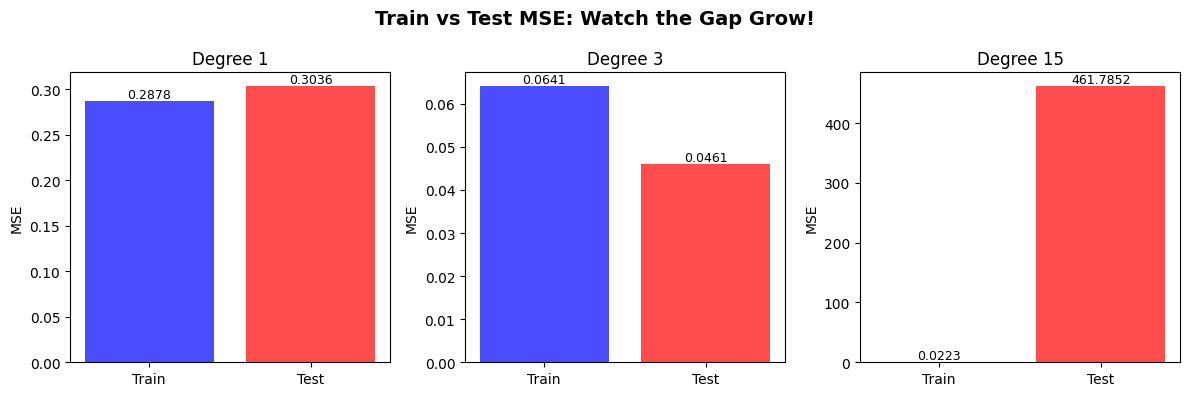


→ Notice: As degree increases, the gap between Train and Test MSE widens!


In [17]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for idx, (degree, train_mse, test_mse) in enumerate([
    (1, train_mse_1, test_mse_1),
    (3, train_mse_3, test_mse_3),
    (15, train_mse_15, test_mse_15)
]):
    bars = axes[idx].bar(['Train', 'Test'], [train_mse, test_mse], color=['blue', 'red'], alpha=0.7)
    axes[idx].set_ylabel('MSE')
    axes[idx].set_title(f'Degree {degree}')

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2, height, f'{height:.4f}',
                       ha='center', va='bottom', fontsize=9)

plt.suptitle('Train vs Test MSE: Watch the Gap Grow!', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n→ Notice: As degree increases, the gap between Train and Test MSE widens!")

---
## 7. Key Indicator #2: Weight Magnitudes Explode

Overfitted models have HUGE weight coefficients.

Why? The model tries to fit every point (including noise) by making extreme adjustments.

In [18]:
# Compare weight norms
print("Weight Norms")
print("-" * 30)
print(f"Degree 1:  ||w|| = {weight_norm_1:.2f}")
print(f"Degree 3:  ||w|| = {weight_norm_3:.2f}")
print(f"Degree 15: ||w|| = {weight_norm_15:.2f}")

Weight Norms
------------------------------
Degree 1:  ||w|| = 2.03
Degree 3:  ||w|| = 39.54
Degree 15: ||w|| = 18199885221.94


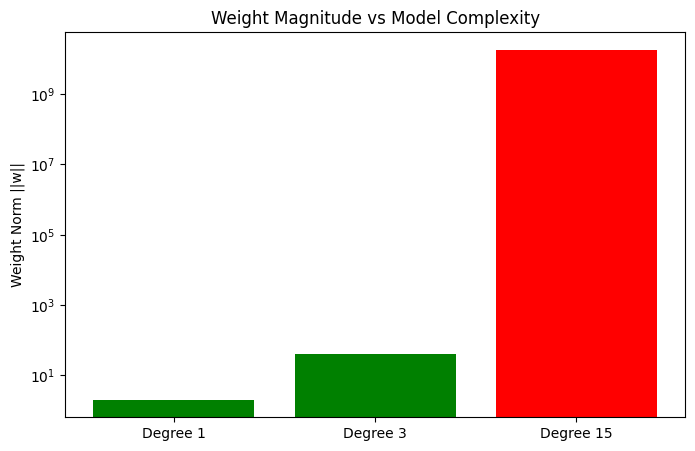


→ Degree 15 weights are MASSIVE compared to simpler models!


In [19]:
# Visualize weight explosion
plt.figure(figsize=(8, 5))
plt.bar(['Degree 1', 'Degree 3', 'Degree 15'],
        [weight_norm_1, weight_norm_3, weight_norm_15],
        color=['green', 'green', 'red'])
plt.ylabel('Weight Norm ||w||')
plt.title('Weight Magnitude vs Model Complexity')
plt.yscale('log')  # Log scale to show the dramatic increase
plt.show()

print("\n→ Degree 15 weights are MASSIVE compared to simpler models!")

---
## 8. Looking at Individual Coefficients

Let's compare the actual coefficient values.

In [20]:
# Degree 3 coefficients
print("Degree 3 Coefficients:")
for i, c in enumerate(model3.coef_):
    print(f"  w{i}: {c:>10.4f}")
print(f"\n  Max |coefficient|: {np.max(np.abs(model3.coef_)):.2f}")

Degree 3 Coefficients:
  w0:     9.6974
  w1:   -31.5351
  w2:    21.7845

  Max |coefficient|: 31.54


In [21]:
# Degree 15 coefficients
print("Degree 15 Coefficients:")
for i, c in enumerate(model15.coef_):
    print(f"  w{i}: {c:>12.2f}")
print(f"\n  Max |coefficient|: {np.max(np.abs(model15.coef_)):.2f}")

Degree 15 Coefficients:
  w0:         0.00
  w1:        32.64
  w2:     -3429.18
  w3:    128734.72
  w4:  -2308754.11
  w5:  24032462.28
  w6: -160693157.80
  w7: 731714311.81
  w8: -2347916807.19
  w9: 5404682588.60
  w10: -8966255791.60
  w11: 10628876127.05
  w12: -8779487690.54
  w13: 4798214005.11
  w14: -1558781321.69
  w15: 227798689.65

  Max |coefficient|: 10628876127.05


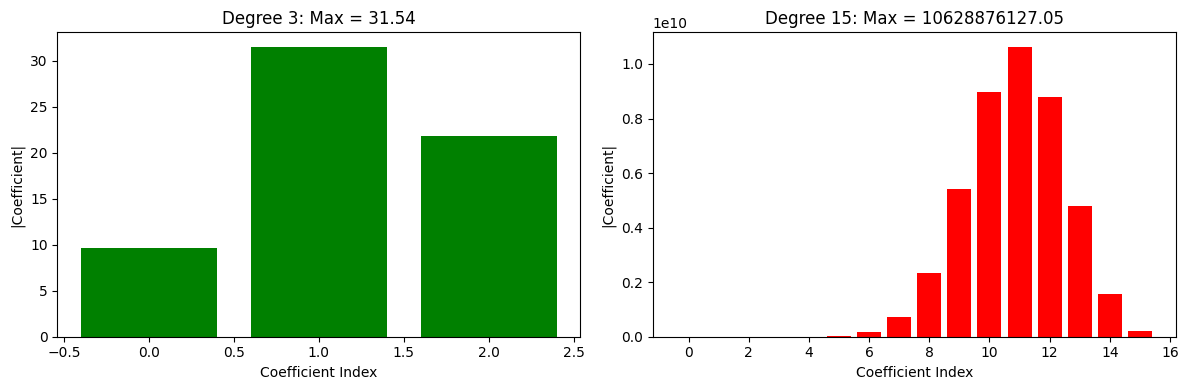

In [22]:
# Visual comparison of coefficient magnitudes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(len(model3.coef_)), np.abs(model3.coef_), color='green')
axes[0].set_xlabel('Coefficient Index')
axes[0].set_ylabel('|Coefficient|')
axes[0].set_title(f'Degree 3: Max = {np.max(np.abs(model3.coef_)):.2f}')

axes[1].bar(range(len(model15.coef_)), np.abs(model15.coef_), color='red')
axes[1].set_xlabel('Coefficient Index')
axes[1].set_ylabel('|Coefficient|')
axes[1].set_title(f'Degree 15: Max = {np.max(np.abs(model15.coef_)):.2f}')

plt.tight_layout()
plt.show()

---
## 9. The Solution: Regularization (Ridge Regression)

**Ridge Regression** adds a penalty for large weights:

$$\text{Loss} = \text{MSE} + \alpha \cdot \sum w_i^2$$

This forces the model to keep weights small → less overfitting.

In [24]:
# Fit Ridge regression on degree 15 features
model_ridge = Ridge(alpha=0.1)
model_ridge.fit(X_train_poly15, y_train)

# Calculate errors
y_train_pred_ridge = model_ridge.predict(X_train_poly15)
y_test_pred_ridge = model_ridge.predict(X_test_poly15)

train_mse_ridge = np.mean((y_train - y_train_pred_ridge) ** 2)
test_mse_ridge = np.mean((y_test - y_test_pred_ridge) ** 2)
weight_norm_ridge = np.sqrt(np.sum(model_ridge.coef_ ** 2))

In [25]:
# Compare: Without vs With Regularization
print("Degree 15 - Without Regularization:")
print(f"  Train MSE:    {train_mse_15:.4f}")
print(f"  Test MSE:     {test_mse_15:.4f}")
print(f"  Weight Norm:  {weight_norm_15:.2f}")

print("\nDegree 15 - With Ridge Regularization:")
print(f"  Train MSE:    {train_mse_ridge:.4f}")
print(f"  Test MSE:     {test_mse_ridge:.4f}")
print(f"  Weight Norm:  {weight_norm_ridge:.2f}")

print(f"\n→ Weight reduction: {weight_norm_15 / weight_norm_ridge:.1f}x smaller!")

Degree 15 - Without Regularization:
  Train MSE:    0.0223
  Test MSE:     461.7852
  Weight Norm:  18199885221.94

Degree 15 - With Ridge Regularization:
  Train MSE:    0.1713
  Test MSE:     0.1461
  Weight Norm:  2.37

→ Weight reduction: 7681062074.2x smaller!


In [ ]:
# Visualize the difference
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Without regularization
y_smooth_no_reg = model15.predict(X_smooth_poly15)
axes[0].scatter(X_train, y_train, color='blue', s=50, label='Train')
axes[0].scatter(X_test, y_test, color='red', s=50, label='Test')
axes[0].plot(X_smooth, y_smooth_no_reg, 'k-', linewidth=2)
axes[0].set_ylim(-2, 2)
axes[0].set_title(f'Without Regularization\nTest MSE: {test_mse_15:.4f}')
axes[0].legend()

# With regularization
y_smooth_ridge = model_ridge.predict(X_smooth_poly15)
axes[1].scatter(X_train, y_train, color='blue', s=50, label='Train')
axes[1].scatter(X_test, y_test, color='red', s=50, label='Test')
axes[1].plot(X_smooth, y_smooth_ridge, 'k-', linewidth=2)
axes[1].set_ylim(-2, 2)
axes[1].set_title(f'With Ridge Regularization\nTest MSE: {test_mse_ridge:.4f}')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 10. Final Summary

### How to Detect Overfitting:

1. **Train-Test Gap**: Training error low, test error high
2. **Large Weights**: Coefficient magnitudes explode

### How to Fix Overfitting:

1. **Reduce model complexity** (fewer parameters)
2. **Regularization** (penalize large weights)
3. **More training data**

In [ ]:
# Final visual summary: Underfitting → Good Fit → Overfitting
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Degree 1 - Underfitting
axes[0].scatter(X_train, y_train, color='blue', s=40)
axes[0].scatter(X_test, y_test, color='red', s=40)
axes[0].plot(X_smooth, y_smooth_pred1, 'k-', linewidth=2)
axes[0].set_ylim(-2, 2)
axes[0].set_title('UNDERFITTING\n(Degree 1)', color='blue', fontweight='bold')

# Degree 3 - Good Fit
axes[1].scatter(X_train, y_train, color='blue', s=40)
axes[1].scatter(X_test, y_test, color='red', s=40)
axes[1].plot(X_smooth, y_smooth_pred3, 'k-', linewidth=2)
axes[1].set_ylim(-2, 2)
axes[1].set_title('GOOD FIT\n(Degree 3)', color='green', fontweight='bold')

# Degree 15 - Overfitting
axes[2].scatter(X_train, y_train, color='blue', s=40)
axes[2].scatter(X_test, y_test, color='red', s=40)
axes[2].plot(X_smooth, y_smooth_pred15, 'k-', linewidth=2)
axes[2].set_ylim(-2, 2)
axes[2].set_title('OVERFITTING\n(Degree 15)', color='red', fontweight='bold')

plt.tight_layout()
plt.show()